In [1]:
import ee
import pandas as pd
import matplotlib.pyplot as plt

ee.Initialize()

counties = ee.FeatureCollection("FAO/GAUL/2015/level2")

makueni = counties.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"),
        ee.Filter.eq("ADM2_NAME", "Makueni")
    )
)

In [2]:
chirps = ee.ImageCollection(
    "UCSB-CHG/CHIRPS/DAILY" # Climate Hazards Group InfraRed Precipitation with Stations - rainfall datasets
)

In [3]:
months = pd.date_range(
    start="2020-01-01",
    end="2024-12-01",
    freq="MS"
)

months

DatetimeIndex(['2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
               '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01',
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
      

In [4]:
def monthly_rainfall(start_date, end_date):

    rain = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
        .filterBounds(makueni)
        .filterDate(start_date, end_date)
        .sum()
    )

    rainfall = rain.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=makueni.geometry(),
        scale=5000, # CHIRPS has a spatial resolution of about 0.05°, which is approximately 5 km × 5 km at the equator.
        maxPixels=1e9
    )

    return rainfall.get("precipitation") # "precipitation is the band (column) in the dataset

In [5]:
print(
    monthly_rainfall(
        "2024-01-01",
        "2024-02-01"
    ).getInfo()
)

63.01005929571195


In [6]:
results = []

for start in months:
    end = start + pd.DateOffset(months=1)

    value = monthly_rainfall(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d")
    ).getInfo()

    results.append({
        "month": start,
        "rainfall_mm": value
    })

In [7]:
rain_df = pd.DataFrame(results)
rain_df

,month,rainfall_mm
0,2020-01-01,118.317911
1,2020-02-01,56.757018
2,2020-03-01,171.246656
3,2020-04-01,202.196964
4,2020-05-01,22.359689
5,2020-06-01,8.792400
6,2020-07-01,11.160580
7,2020-08-01,6.516741
8,2020-09-01,6.753315
9,2020-10-01,19.448646


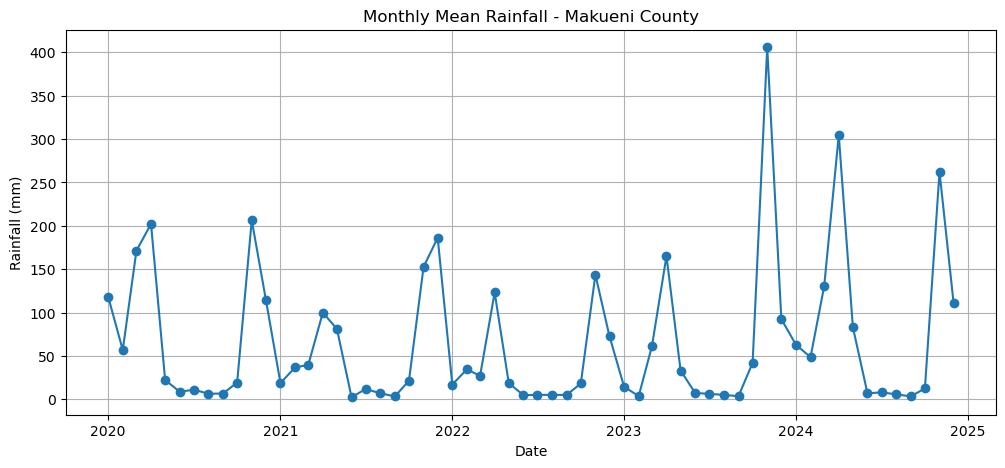

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(rain_df["month"], rain_df["rainfall_mm"], marker="o")
plt.title("Monthly Mean Rainfall - Makueni County")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Date")
plt.grid(True)

plt.savefig(
    "../docs/images/makueni_rainfall_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
rain_df.to_csv(
    "../outputs/makueni_monthly_rainfall_2020_2024.csv",
    index=False
)